In [1]:
# Import required libraries
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np


In [2]:
# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 33s 0us/step 


In [3]:
# Normalize pixel values (0–255 to 0–1)
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0


In [4]:
# Define class labels
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']


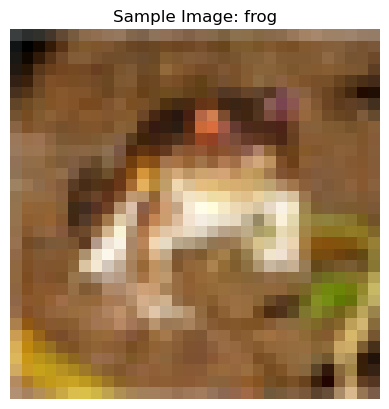

In [6]:
# Display one sample image (FIXED VERSION)
plt.imshow(x_train[0])

# Correct way to extract label
label = y_train[0][0]

plt.title("Sample Image: " + class_names[label])
plt.axis('off')
plt.show()



In [8]:
# Build CNN model (UPDATED - NO WARNING)
model = models.Sequential()

# Add Input layer FIRST (recommended way)
model.add(tf.keras.Input(shape=(32, 32, 3)))

# Convolution + Pooling layers
model.add(layers.Conv2D(32, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))

# Flatten + Dense layers
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))



In [10]:
# Compile the CNN model
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy()]
)



In [11]:
# Train the model (clean output)

import warnings
warnings.filterwarnings('ignore')   # Hide Python warnings

history = model.fit(
    x_train, y_train,
    epochs=5,            # Safe value
    batch_size=64,       # Memory efficient
    validation_data=(x_test, y_test),
    verbose=2            # Cleaner output (less noisy than 1)
)


Epoch 1/5
782/782 - 13s - 16ms/step - loss: 1.5688 - sparse_categorical_accuracy: 0.4249 - val_loss: 1.3014 - val_sparse_categorical_accuracy: 0.5275
Epoch 2/5
782/782 - 18s - 22ms/step - loss: 1.2183 - sparse_categorical_accuracy: 0.5688 - val_loss: 1.1349 - val_sparse_categorical_accuracy: 0.6004
Epoch 3/5
782/782 - 17s - 22ms/step - loss: 1.0634 - sparse_categorical_accuracy: 0.6250 - val_loss: 1.0430 - val_sparse_categorical_accuracy: 0.6338
Epoch 4/5
782/782 - 15s - 20ms/step - loss: 0.9722 - sparse_categorical_accuracy: 0.6596 - val_loss: 1.0278 - val_sparse_categorical_accuracy: 0.6350
Epoch 5/5
782/782 - 17s - 22ms/step - loss: 0.9031 - sparse_categorical_accuracy: 0.6868 - val_loss: 0.9273 - val_sparse_categorical_accuracy: 0.6748


In [12]:
# Evaluate model (clean & silent)

import warnings
warnings.filterwarnings('ignore')   # Hide Python warnings

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Hide TensorFlow logs

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

print("Test Accuracy:", round(test_acc, 4))


Test Accuracy: 0.6748


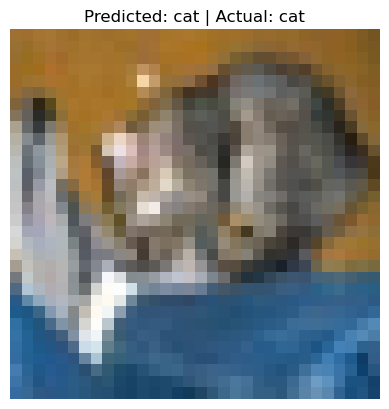

In [13]:
# Make predictions (clean & silent)

import warnings
warnings.filterwarnings('ignore')   # Hide Python warnings

# Suppress TensorFlow logs
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Predict without progress bar
predictions = model.predict(x_test, verbose=0)

# Get predicted class safely
predicted_class = int(np.argmax(predictions[0]))

# Get actual class safely
actual_class = int(y_test[0][0])

# Display image with prediction
plt.imshow(x_test[0])
plt.title("Predicted: " + class_names[predicted_class] +
          " | Actual: " + class_names[actual_class])
plt.axis('off')
plt.show()
